# SESSION 06: IMAGE RESTORATION (SHARPENING) AND MORPHOLOGY

- Ex6_1: Image Sharpening
- Ex6_2: Image Restoration using Butterworth and Wiener filters
- Ex6_3: Dilation with different SEs
- Ex6_4: Erosion with different SEs
- Ex6_5: Circle Counting with
- Ex6_6: Hole Detection using Erosion
- Ex6_7: Hole Removal using Closing (Dilation + Erosion)
- Ex6_8: Edge Detection using Dilation and Erosion
- Ex6_9: Cascade Dilation

In [1]:
# connect GG Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# load packages
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Create a path link to Session folder
PATH = '/content/drive/MyDrive/IVP/Session_06/'

# Font size for figures
FS = 12

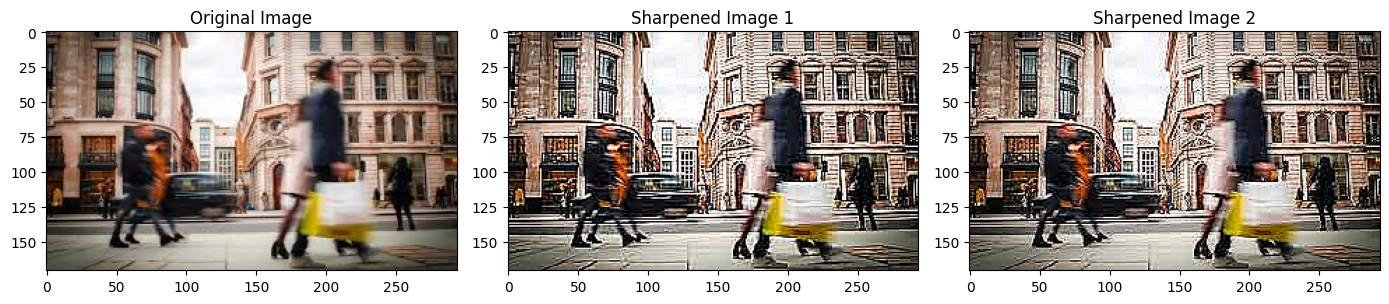

In [4]:
#Ex6_1: Image Sharpening
Img = cv2.imread(PATH + 'blurring.jpg', cv2.IMREAD_COLOR_RGB)

# Create two simple filter for image sharpening
# Search: image filter sharping matrix
h1 = np.array([[-1, -1, -1], [-1, 10, -1], [-1, -1, -1]], dtype=np.float64) / 2
h2 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float64)

# apply two filters to the original image
Img_sharpened1 = cv2.filter2D(Img, -1, h1, borderType=cv2.BORDER_REPLICATE)
Img_sharpened2 = cv2.filter2D(Img, -1, h2, borderType=cv2.BORDER_REPLICATE)

# display results
plt.figure(figsize=(14, 10))

plt.subplot(1,3,1), plt.imshow(Img), plt.title('Original Image', fontsize=FS)
plt.subplot(1,3,2), plt.imshow(Img_sharpened1), plt.title('Sharpened Image 1', fontsize=FS)
plt.subplot(1,3,3), plt.imshow(Img_sharpened2), plt.title('Sharpened Image 2', fontsize=FS)
plt.tight_layout()
plt.savefig(PATH + 'Ex6_1.jpg', dpi=400)
plt.show()


This cell, labeled 'Ex6_1: Image Sharpening', demonstrates image sharpening using convolution with two different sharpening kernels.

1.  **Load Image**: Reads `blurring.jpg` from the specified `PATH`.
2.  **Define Sharpening Kernels**: `h1` and `h2` are 3x3 matrices (kernels) designed to enhance edges and details when convolved with an image. `h1` includes a division by 2 to prevent over-sharpening.
3.  **Apply Filters**: `cv2.filter2D()` applies each kernel to the original image (`Img`) to produce `Img_sharpened1` and `Img_sharpened2`. The `-1` argument indicates that the output image will have the same depth as the source. `borderType=cv2.BORDER_REPLICATE` handles pixels at the image borders.
4.  **Display Results**: Uses `matplotlib` to display the original image alongside the two sharpened versions for visual comparison. `plt.tight_layout()` adjusts plot parameters for a tight layout.

MSE between the original image and noisy blurry image: 0.03675114098282887


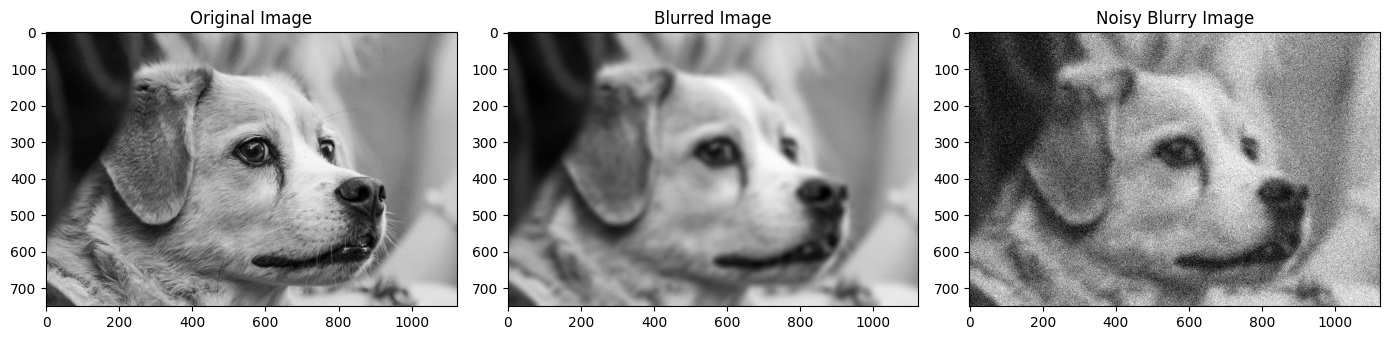

In [5]:
#Ex 6_2: Image Restoration using Butterworth and Wiener filters
from scipy.signal import butter, wiener
from scipy.signal import convolve2d as con2d
from skimage.restoration import wiener
from skimage.util import random_noise

# load image

Img = cv2.imread(PATH + 'puppy.jpeg', cv2.IMREAD_COLOR_RGB)

# convert from RGB to GRAYSCALE, then normalize to double format (0.0000 -> 1.0000)
Img = cv2.cvtColor(Img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0


#make the original image blurry the noisy
#stage 1: blurry image with LENGTH, ANGLE = 21, 10
blurry_Img = cv2.GaussianBlur(Img, (21, 21), 10)

#stage 2: noisy blurry image
noise_mean, noise_var = 0, 0.04
noisy_blurry_Img = random_noise(blurry_Img, mode='gaussian', mean=noise_mean, var=noise_var)
noisy_blurry_Img = np.clip(noisy_blurry_Img, 0.0, 1.0)

# calculate the Mean Square Error (MSE) between the original image and the noisy blurry image
def MSE(img1, img2):
  return np.mean((img1 - img2) ** 2)


mse1 = MSE(Img, noisy_blurry_Img)
print(f'MSE between the original image and noisy blurry image: {mse1}')
# display results
plt.figure(figsize=(14, 10))

plt.subplot(1,3,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS)
plt.subplot(1,3,2), plt.imshow(blurry_Img, cmap='gray'), plt.title('Blurred Image', fontsize=FS)
plt.subplot(1,3,3), plt.imshow(noisy_blurry_Img, cmap='gray'), plt.title('Noisy Blurry Image', fontsize=FS)
plt.tight_layout()
plt.savefig(PATH + 'Ex6_2a.jpg', dpi=400)
plt.show()

This cell, labeled 'Ex 6_2: Image Restoration using Butterworth and Wiener filters', prepares an image by blurring it and adding noise, then defines a function to calculate Mean Squared Error (MSE).

1.  **Import Libraries**: Imports `butter`, `wiener` (from `scipy.signal` and `skimage.restoration`), `convolve2d`, and `random_noise`.
2.  **Load and Preprocess Image**: Reads `puppy.jpeg`, converts it to grayscale, and normalizes pixel values to a float range [0.0, 1.0].
3.  **Simulate Blurring**: Applies a Gaussian blur (`cv2.GaussianBlur`) to create `blurry_Img`.
4.  **Add Noise**: Introduces Gaussian noise to the blurred image using `random_noise()` to create `noisy_blurry_Img`. The `np.clip()` function ensures pixel values remain within the valid range.
5.  **MSE Function**: Defines `MSE(img1, img2)` to calculate the Mean Squared Error between two images, providing a quantitative measure of similarity.
6.  **Calculate Initial MSE**: Computes and prints the MSE between the original image and the `noisy_blurry_Img`.
7.  **Display Results**: Shows the original, blurred, and noisy blurred images using `matplotlib` to visualize the degradation.

MSE between the original image and the filtered image: 0.005965720060000522
MSE between the original image and the filtered image: 0.0037195802941330696


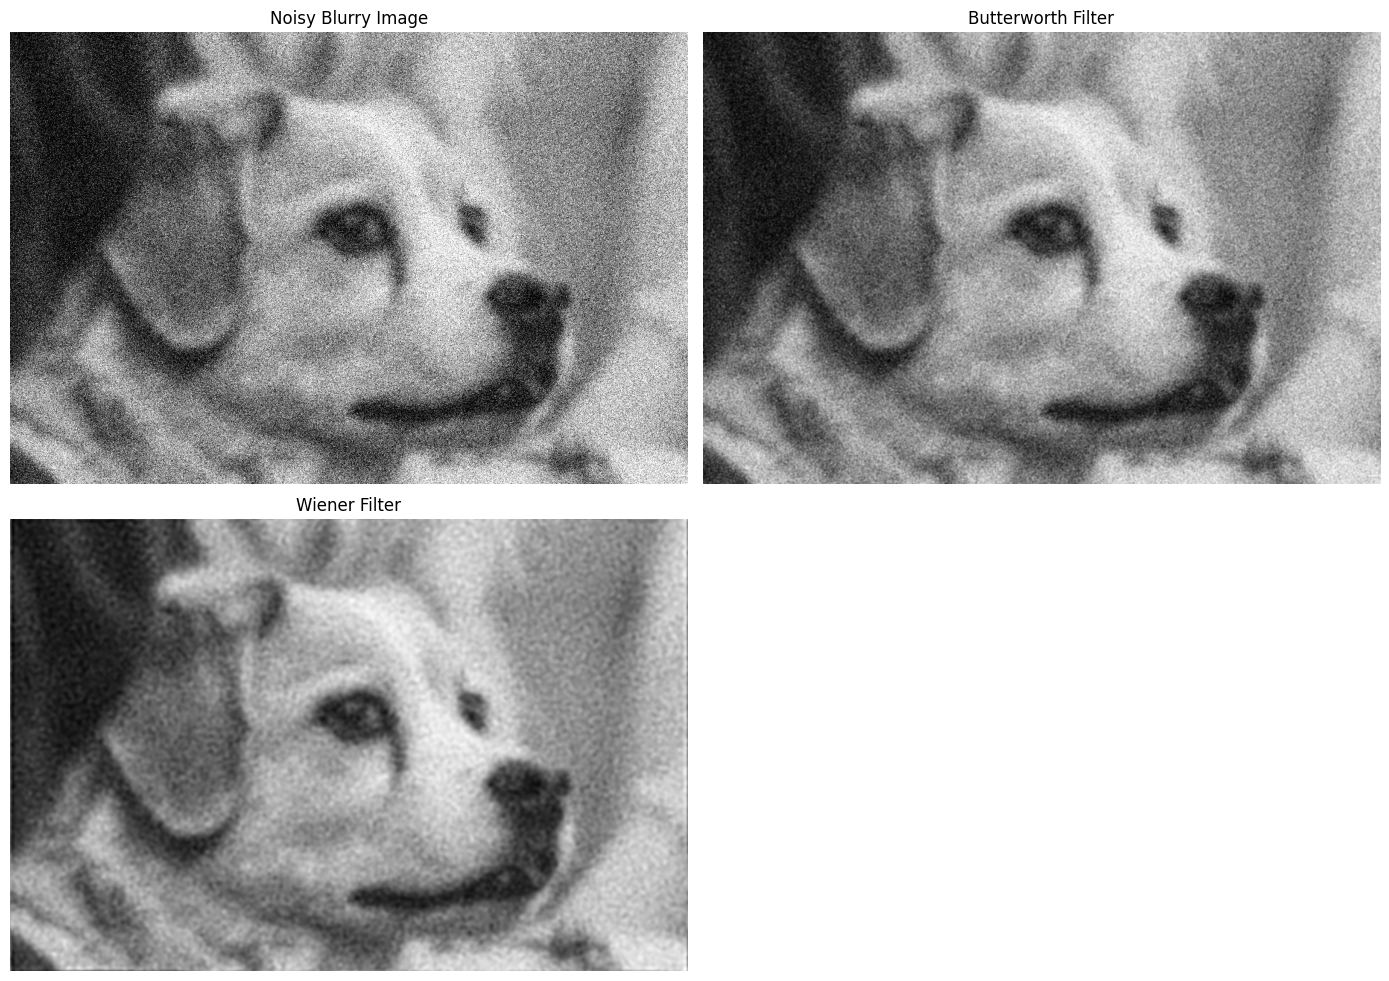

In [6]:

# Restoration process
plt.figure(figsize=(14, 10))

plt.subplot(2,2,1), plt.imshow(noisy_blurry_Img, cmap='gray'), plt.title('Noisy Blurry Image', fontsize=FS), plt.axis('off')

# a. using Butterworth filter
# design a 1-D Butterworth low-pass filter (LPF)
order = 3 # order = 2-4: usually enough, higher orders can cause ringing artifacts.
          # Choose an order based on:
          #1. removes most of th grain
          #2. still keeps edges (lines, contours...) reasonably sharp
cutoff = 0.12 # normalized cutoff (0->1, 1 => Nyquist)
              # for heavy noise:
              # 1. Lower cutoff (0.05-0.10): stronger denoising, but more blur
              # 2. Higher cutoff (0.15-0.25): keep edges, but leaves some noise
b, a = butter(order, cutoff, btype='low', analog=False)

# turn numerator coefficients into a small separable 2-D kernel
kernel_1d = b / np.sum(b) #normalize
kernel_2d = np.outer(kernel_1d, kernel_1d) #outer product

# apply via 2-D convolution
Img_butter = con2d(noisy_blurry_Img, kernel_2d, mode='same', boundary='symm')
Img_butter = np.clip(Img_butter, 0.0, 1.0)

plt.subplot(2,2,2), plt.imshow(Img_butter, cmap='gray'), plt.title('Butterworth Filter', fontsize=FS), plt.axis('off')

mse2 = MSE(Img, Img_butter)
print(f'MSE between the original image and the filtered image: {mse2}')

# b. using Wiener filter
psf_size = 7
sigma = 5

x = np.linspace(-(psf_size // 2), psf_size // 2, psf_size)
X, Y = np.meshgrid(x, x)
psf = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
psf = psf / np.sum(psf)

# apply Wiener filter to the noise blurry image
Img_wiener = wiener(noisy_blurry_Img, psf, balance=5.1, clip=True)

plt.subplot(2,2,3), plt.imshow(Img_wiener, cmap='gray'), plt.title('Wiener Filter', fontsize=FS), plt.axis('off')

mse3 = MSE(Img, Img_wiener)
print(f'MSE between the original image and the filtered image: {mse3}')

plt.tight_layout()
plt.savefig(PATH + 'Ex6_2b.jpg', dpi=400)
plt.show()


This cell continues 'Ex 6_2' by demonstrating image restoration using Butterworth and Wiener filters.

1.  **Display Noisy Blurry Image**: Shows the `noisy_blurry_Img` as a reference.
2.  **Butterworth Filter**:
    - **Design**: A 1-D Butterworth low-pass filter is designed using `butter()` with specified `order` and `cutoff` frequency. This filter is known for its smooth frequency response.
    - **Kernel Creation**: The 1-D coefficients are converted into a 2-D separable kernel.
    - **Application**: The filter is applied to the `noisy_blurry_Img` using `con2d` (2-D convolution) to produce `Img_butter`. `np.clip()` is used to keep pixel values within [0.0, 1.0].
    - **Display and MSE**: The Butterworth-filtered image is displayed, and its MSE with the original image is calculated and printed.
3.  **Wiener Filter**:
    - **PSF Generation**: A Point Spread Function (PSF) is created using a 2D Gaussian function. The PSF represents the blur kernel.
    - **Application**: The `wiener()` function from `skimage.restoration` is applied to the `noisy_blurry_Img` along with the PSF to produce `Img_wiener`. The `balance` parameter controls the trade-off between noise reduction and deblurring.
    - **Display and MSE**: The Wiener-filtered image is displayed, and its MSE with the original image is calculated and printed.

This cell effectively compares the restoration capabilities of two different filtering techniques.

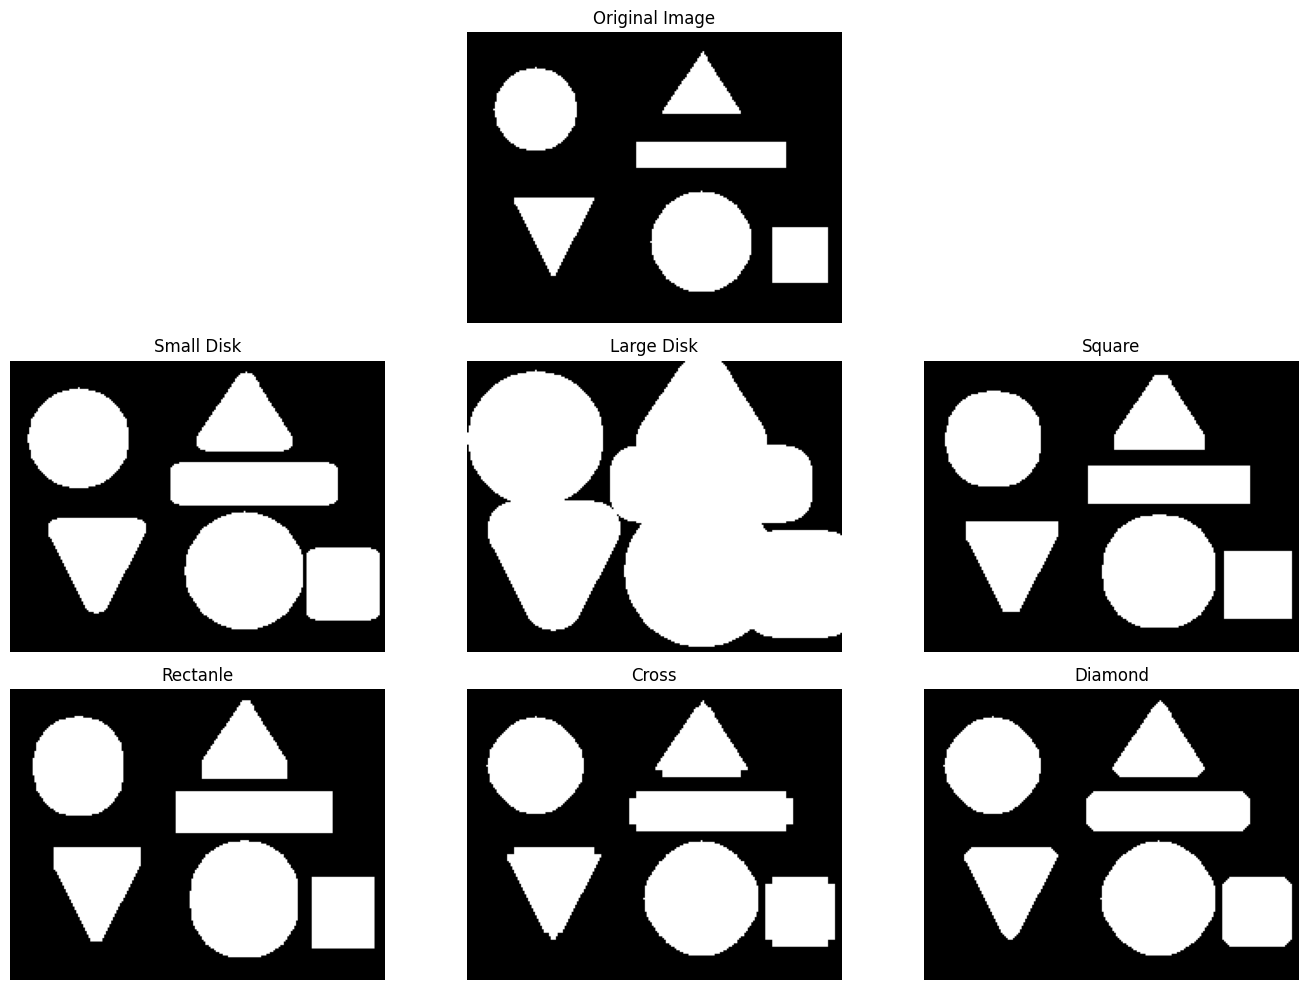

In [7]:
#Ex6_3: Dilation with different SEs

Img = cv2.imread(PATH + 'binary_objects.jpg', cv2.IMREAD_GRAYSCALE)

# convert from grayscal to binary
_, Img = cv2.threshold(Img, 127, 255, cv2.THRESH_BINARY)

# perform the dilation
# a. small disk with radius = 5
se1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
bw1 = cv2.dilate(Img, se1)

# b. large disk with radius = 15
se2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
bw2 = cv2.dilate(Img, se2)

# c. square with side = 8
se3 = cv2.getStructuringElement(cv2.MORPH_RECT, (8, 8))
bw3 = cv2.dilate(Img, se3)

# d. rectanle with 2 sides = 5x10
se4 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 10))
bw4 = cv2.dilate(Img, se4)

# e. cross with radius = 4
se5 = cv2.getStructuringElement(cv2.MORPH_CROSS, (9, 9))
bw5 = cv2.dilate(Img, se5)

# f. diamond with radius = 4
se6 = cv2.getStructuringElement(cv2.MORPH_DIAMOND, (9, 9))
bw6 = cv2.dilate(Img, se6)

# display results
plt.figure(figsize=(14, 10))

plt.subplot(3,3,2), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(3,3,4), plt.imshow(bw1, cmap='gray'), plt.title('Small Disk', fontsize=FS), plt.axis('off')
plt.subplot(3,3,5), plt.imshow(bw2, cmap='gray'), plt.title('Large Disk', fontsize=FS), plt.axis('off')
plt.subplot(3,3,6), plt.imshow(bw3, cmap='gray'), plt.title('Square', fontsize=FS), plt.axis('off')
plt.subplot(3,3,7), plt.imshow(bw4, cmap='gray'), plt.title('Rectanle', fontsize=FS), plt.axis('off')
plt.subplot(3,3,8), plt.imshow(bw5, cmap='gray'), plt.title('Cross', fontsize=FS), plt.axis('off')
plt.subplot(3,3,9), plt.imshow(bw6, cmap='gray'), plt.title('Diamond', fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex6_3.jpg', dpi=400)
plt.show()

This cell, 'Ex6_3: Dilation with different SEs', demonstrates the morphological operation of dilation using various structuring elements (SEs).

1.  **Load and Binarize Image**: Reads `binary_objects.jpg` in grayscale and converts it to a binary image using a threshold.
2.  **Define Structuring Elements (SEs)**: Several SEs are created using `cv2.getStructuringElement()` with different shapes (ellipse, rectangle, cross, diamond) and sizes:
    - `se1`: Small ellipse (disk).
    - `se2`: Large ellipse (disk).
    - `se3`: Square.
    - `se4`: Rectangle.
    - `se5`: Cross.
    - `se6`: Diamond.
3.  **Perform Dilation**: `cv2.dilate()` applies each SE to the binary image, expanding the white (foreground) regions.
4.  **Display Results**: Shows the original binary image and the results of dilation with each of the six different structuring elements, illustrating how different SEs affect the dilation outcome.

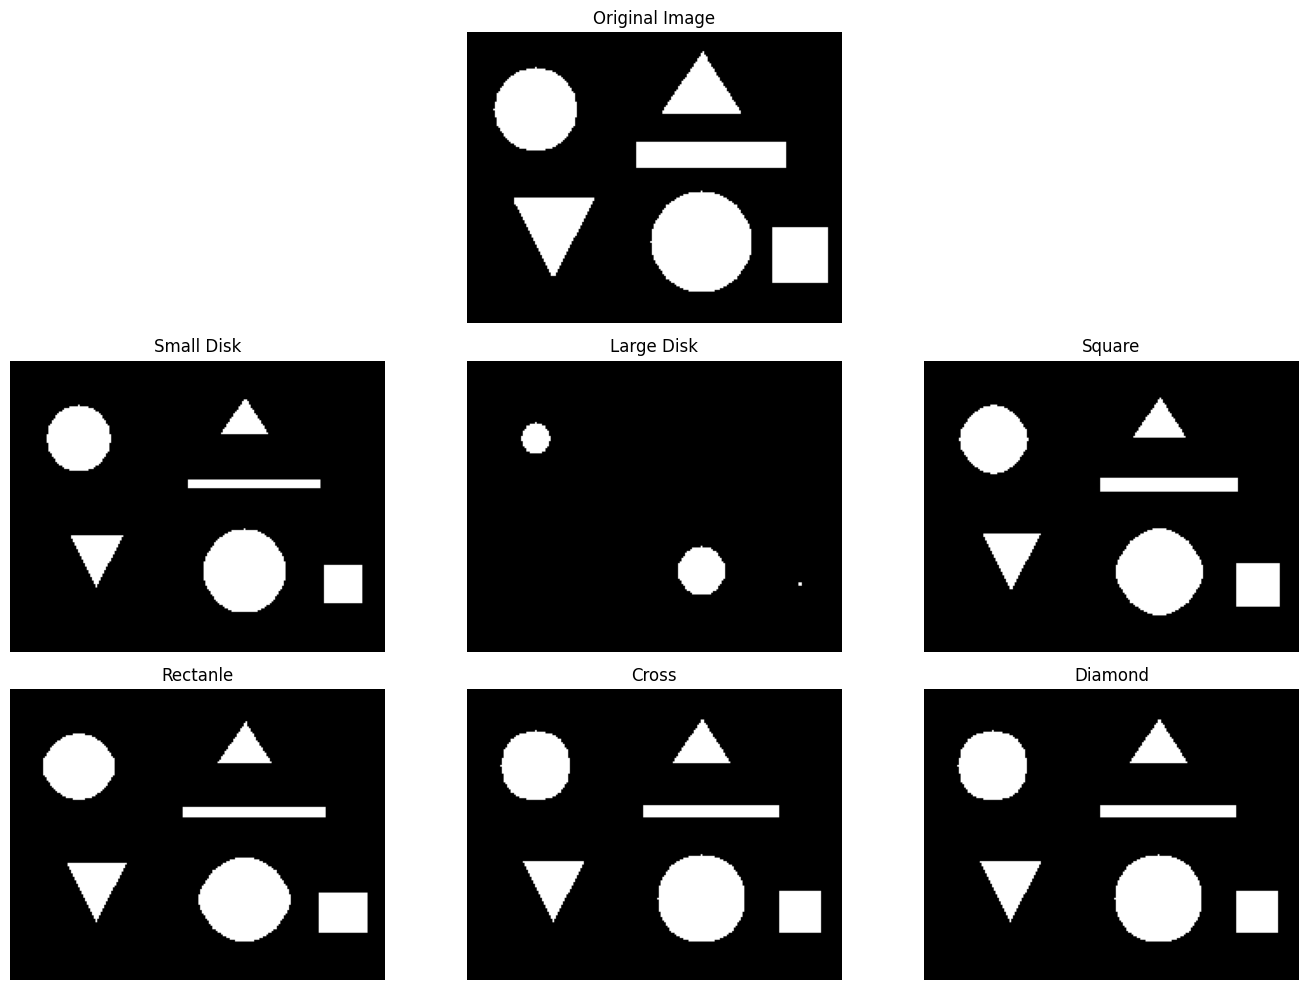

In [8]:
#Ex6_4: Erosion with different SEs

Img = cv2.imread(PATH + 'binary_objects.jpg', cv2.IMREAD_GRAYSCALE)

# convert from grayscal to binary
_, Img = cv2.threshold(Img, 127, 255, cv2.THRESH_BINARY)

# perform the dilation
# a. small disk with radius = 5
se1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
bw1 = cv2.erode(Img, se1)

# b. large disk with radius = 15
se2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
bw2 = cv2.erode(Img, se2)

# c. square with side = 8
se3 = cv2.getStructuringElement(cv2.MORPH_RECT, (8, 8))
bw3 = cv2.erode(Img, se3)

# d. rectanle with 2 sides = 5x10
se4 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 10))
bw4 = cv2.erode(Img, se4)

# e. cross with radius = 4
se5 = cv2.getStructuringElement(cv2.MORPH_CROSS, (9, 9))
bw5 = cv2.erode(Img, se5)

# f. diamond with radius = 4
se6 = cv2.getStructuringElement(cv2.MORPH_DIAMOND, (9, 9))
bw6 = cv2.erode(Img, se6)

# display results
plt.figure(figsize=(14, 10))

plt.subplot(3,3,2), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(3,3,4), plt.imshow(bw1, cmap='gray'), plt.title('Small Disk', fontsize=FS), plt.axis('off')
plt.subplot(3,3,5), plt.imshow(bw2, cmap='gray'), plt.title('Large Disk', fontsize=FS), plt.axis('off')
plt.subplot(3,3,6), plt.imshow(bw3, cmap='gray'), plt.title('Square', fontsize=FS), plt.axis('off')
plt.subplot(3,3,7), plt.imshow(bw4, cmap='gray'), plt.title('Rectanle', fontsize=FS), plt.axis('off')
plt.subplot(3,3,8), plt.imshow(bw5, cmap='gray'), plt.title('Cross', fontsize=FS), plt.axis('off')
plt.subplot(3,3,9), plt.imshow(bw6, cmap='gray'), plt.title('Diamond', fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.show()

This cell, also labeled 'Ex6_4: Erosion with different SEs', demonstrates the morphological operation of erosion, which is the counterpart to dilation.

1.  **Load and Binarize Image**: Similar to the previous cell, it loads `binary_objects.jpg` and converts it to a binary image.
2.  **Define Structuring Elements (SEs)**: The same set of six structuring elements (ellipse, rectangle, cross, diamond with various sizes) as in the dilation example are created.
3.  **Perform Erosion**: `cv2.erode()` applies each SE to the binary image, shrinking the white (foreground) regions and removing small objects or bridges.
4.  **Display Results**: Displays the original binary image and the results of erosion with each of the six different structuring elements, showcasing how different SEs impact the erosion outcome.

Number of circles before erosion: 1
Number of circles after erosion: 13


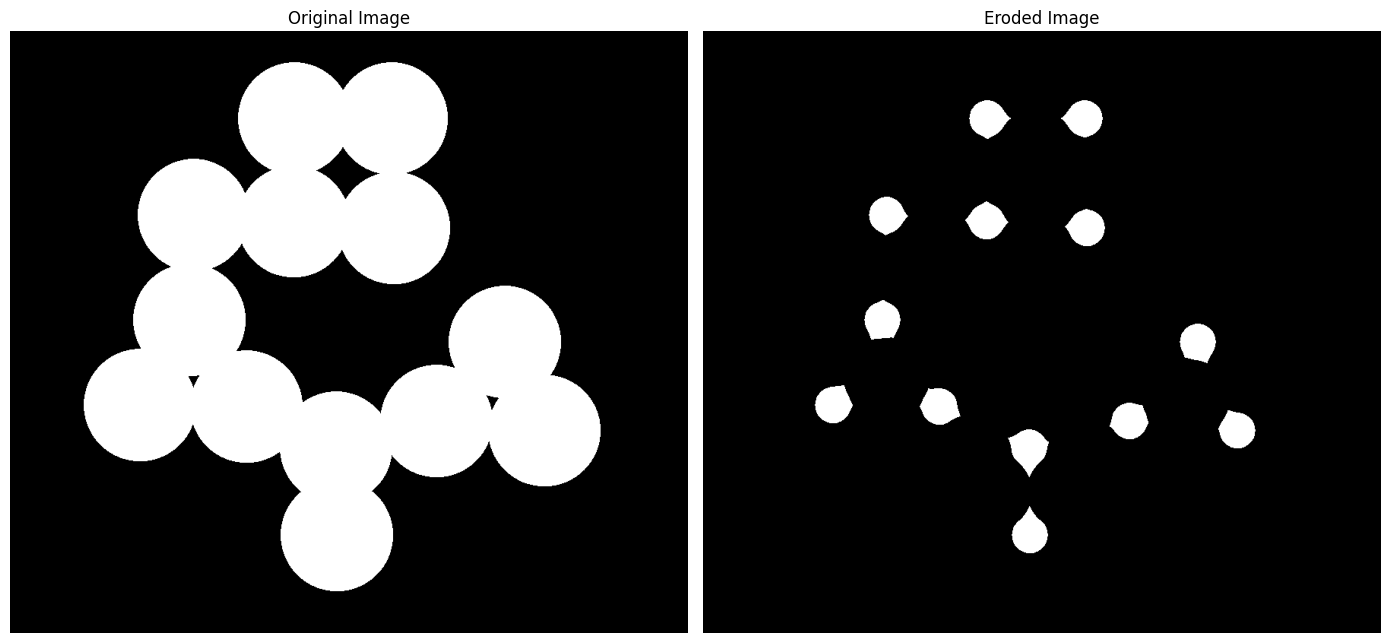

In [9]:
# Ex6_5: Cirle counting with Erosion
Img = cv2.imread(PATH + 'circles.png', cv2.IMREAD_GRAYSCALE)

# convert from GRAYSCALE to BINARY
_, Img = cv2.threshold(Img, 127, 255, cv2.THRESH_BINARY)

# count the number of circles before erosion
num_circles, _ = cv2.connectedComponents(Img, connectivity=4)
print(f'Number of circles before erosion: {num_circles - 1}')

# perform erosion
# create a disk SE with radius = 50
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (101, 101))

# perform the erosion
bw = cv2.erode(Img, se)

# count the number of circles after erosion
num_circles, _ = cv2.connectedComponents(bw, connectivity=4)
print(f'Number of circles after erosion: {num_circles - 1}')

#display results
plt.figure(figsize=(14, 10))

plt.subplot(1,2,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(1,2,2), plt.imshow(bw, cmap='gray'), plt.title('Eroded Image', fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.show()


This cell, 'Ex6_5: Circle counting with Erosion', demonstrates how erosion can be used to separate and count objects.

1.  **Load and Binarize Image**: Reads `circles.png` in grayscale and converts it to a binary image.
2.  **Initial Circle Count**: `cv2.connectedComponents()` is used to count connected components (potential circles) before erosion. The `-1` is to exclude the background component.
3.  **Define Structuring Element**: A large elliptical structuring element (`se`) with a radius of 50 (resulting in a 101x101 kernel) is created. This large SE is chosen to erode away connections between objects, effectively separating them.
4.  **Perform Erosion**: `cv2.erode()` applies the large `se` to the binary image.
5.  **Final Circle Count**: `cv2.connectedComponents()` is used again to count the connected components after erosion. The expectation is that erosion separates overlapping or connected circles, leading to a more accurate count of individual circles.
6.  **Display Results**: Shows the original and the eroded binary images to visually illustrate the effect of erosion on the circles.

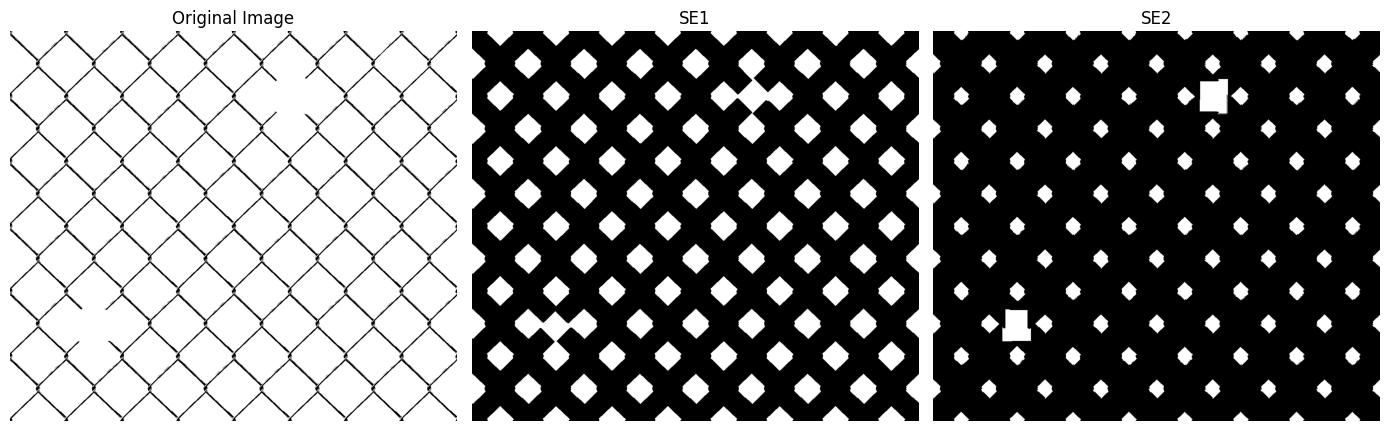

In [10]:
#Ex6_6: Hole detection using Erosion

Img = cv2.imread(PATH + 'fence.jpg', cv2.IMREAD_GRAYSCALE)

#convert from GRAYSCALE to BINARY
_, Img = cv2.threshold(Img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU) # dua tre pho de lay nguong
Img = cv2.bitwise_not(Img) # nen trang luoi den

#use two different SEs to find out the hole(s)
#a. diamond with radius = 35
se1 = cv2.getStructuringElement(cv2.MORPH_DIAMOND, (71, 71))
bw1 = cv2.erode(Img, se1)

#b. cross with radius = 50
se2 = cv2.getStructuringElement(cv2.MORPH_CROSS, (101, 101))
bw2 = cv2.erode(Img, se2)

#display results
plt.figure(figsize=(14, 10))

plt.subplot(1,3,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(1,3,2), plt.imshow(bw1, cmap='gray'), plt.title('SE1', fontsize=FS), plt.axis('off')
plt.subplot(1,3,3), plt.imshow(bw2, cmap='gray'), plt.title('SE2', fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.show()

This cell, 'Ex6_6: Hole detection using Erosion', illustrates how erosion can be used to detect holes or gaps within objects.

1.  **Load and Binarize Image**: Reads `fence.jpg` in grayscale and converts it to a binary image using `cv2.THRESH_OTSU` for automatic thresholding. `cv2.THRESH_BINARY_INV` inverts the threshold, making the objects white and background black. `cv2.bitwise_not()` is then applied to invert it back, making objects black and background white (often representing fences or structures with holes).
2.  **Define Structuring Elements (SEs)**: Two different structuring elements are created:
    - `se1`: A diamond-shaped SE with a radius of 35 (71x71 kernel).
    - `se2`: A cross-shaped SE with a radius of 50 (101x101 kernel).
3.  **Perform Erosion**: `cv2.erode()` applies each of these large SEs to the binary image. When applied to an image where objects are black and background is white, erosion will 'expand' the white areas into the black objects, effectively revealing holes or gaps that are larger than the structuring element.
4.  **Display Results**: Shows the original binary image and the results of erosion with the two different SEs, highlighting how holes or thin structures are 'opened up' by erosion.

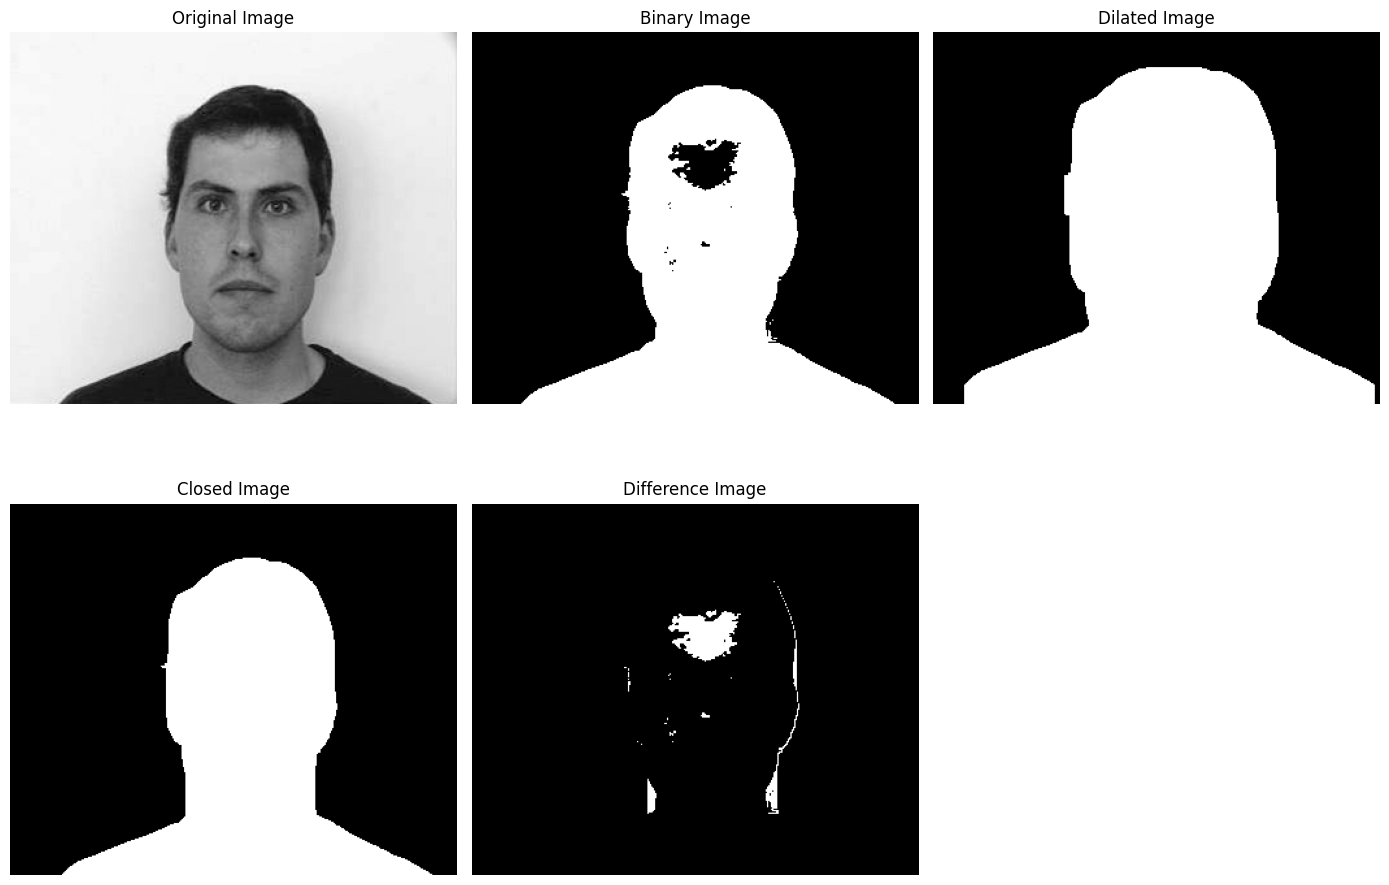

In [11]:
#Ex6_7: Hole Removal using Closing (Dilation + Erosion)
Img = cv2.imread(PATH + 'man_face.png', cv2.IMREAD_GRAYSCALE)

#convert from GRAYSCALE to BINARY
_, Img_bw = cv2.threshold(Img, 110, 255, cv2.THRESH_BINARY_INV)

#create a square with side = 30
se = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 30))

#perform image closing
Img_dilated = cv2.dilate(Img_bw, se)
Img_closed = cv2.erode(Img_dilated, se)
#Img_closed = cv2.morphologyEx(Img_bw, cv2.MORPH_CLOSE, se)

#calculate the difference between Closed Image and Binary Image
#Img_diff = Img_closed - Img_bw
Img_diff = cv2.subtract(Img_closed, Img_bw)

#display results
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 2), plt.imshow(Img_bw, cmap='gray'), plt.title('Binary Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 3), plt.imshow(Img_dilated, cmap='gray'), plt.title('Dilated Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 4), plt.imshow(Img_closed, cmap='gray'), plt.title('Closed Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 5), plt.imshow(Img_diff, cmap='gray'), plt.title('Difference Image', fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex6_7.jpg', dpi=400)
plt.show()


This cell, 'Ex6_7: Hole Removal using Closing (Dilation + Erosion)', demonstrates the morphological operation of closing, which is used to fill small holes and gaps within objects while preserving their overall shape.

1.  **Load and Binarize Image**: Reads `man_face.png` in grayscale and converts it to a binary image (`Img_bw`) using a fixed threshold of 110 and `cv2.THRESH_BINARY_INV` to make the face black and holes white.
2.  **Define Structuring Element**: A square structuring element (`se`) of size 30x30 is created.
3.  **Perform Closing Manually**: Closing is performed by applying dilation followed by erosion using the same structuring element:
    - `Img_dilated = cv2.dilate(Img_bw, se)`: The image is first dilated, which fills small holes.
    - `Img_closed = cv2.erode(Img_dilated, se)`: The dilated image is then eroded, which restores the object's original size but keeps the holes filled.
    - *(Commented out alternative: `cv2.morphologyEx(Img_bw, cv2.MORPH_CLOSE, se)` shows the direct OpenCV function for closing).*
4.  **Calculate Difference**: `Img_diff = cv2.subtract(Img_closed, Img_bw)` calculates the difference between the closed image and the original binary image. This difference image will highlight the areas that were filled by the closing operation (i.e., the removed holes).
5.  **Display Results**: Shows the original grayscale image, the closed binary image, and the difference image, visually demonstrating the hole removal effect of the closing operation.

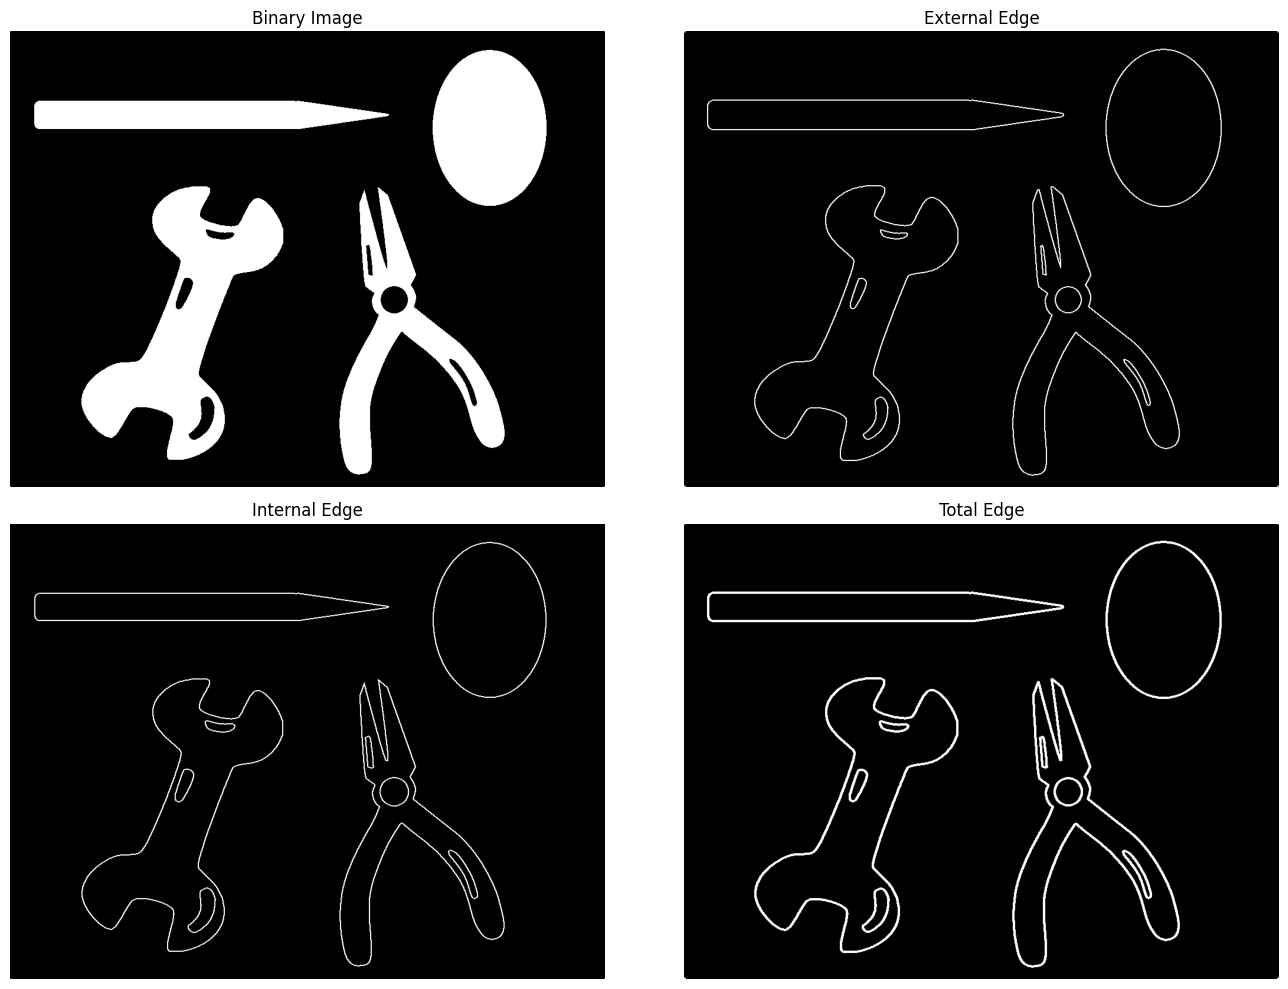

In [12]:
#Ex6_8: Edge Detection using Dilation and Erosion
Img = cv2.imread(PATH + 'cliparts.png', cv2.IMREAD_GRAYSCALE)

# Convert from GRAYSCALE to BINARY using an auto threshold
_, Img_bw = cv2.threshold(Img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Create a disk SE with radius = 2
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Perform image dilation and erosion
Img_dilated = cv2.dilate(Img_bw, se)
Img_eroded = cv2.erode(Img_bw, se)

# Find edges by differences
ext_edge = Img_dilated - Img_bw
int_edge = Img_bw - Img_eroded
total_edge = Img_dilated - Img_eroded

# Display results
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1), plt.imshow(Img_bw, cmap='gray'), plt.title('Binary Image', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 2), plt.imshow(ext_edge, cmap='gray'), plt.title('External Edge', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 3), plt.imshow(int_edge, cmap='gray'), plt.title('Internal Edge', fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 4), plt.imshow(total_edge, cmap='gray'), plt.title('Total Edge', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex6_8.jpg', dpi=400)
plt.show()

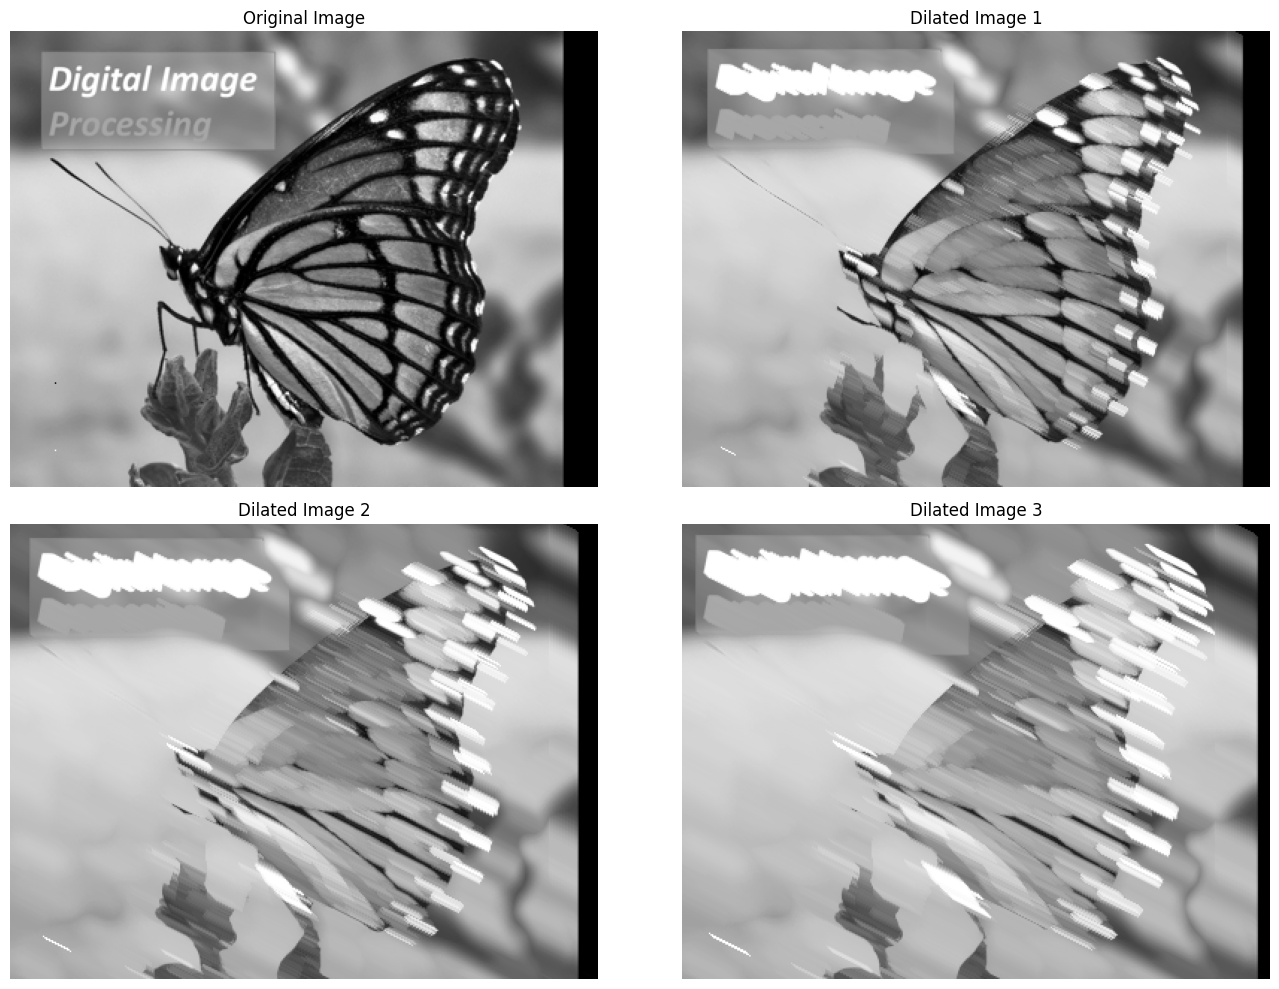

In [13]:
#Ex6_9: Cascade dilation
Img = cv2.imread(PATH + 'butterfly.png', cv2.IMREAD_GRAYSCALE)

#convert from GRAYSCALE to BINARY
#_, Img = cv2.threshold(Img, 127, 255, cv2.THRESH_BINARY)

#define a structuring element 'line' inclined and angle 'theta' in degree
def line_se(length, angle):
  size = length
  kernel = np.zeros((size, size), dtype=np.uint8)

  center = size // 2
  theta = np.deg2rad(angle)

  x1 = int(center - (length // 2) * np.cos(theta))
  y1 = int(center - (length // 2) * np.sin(theta))
  x2 = int(center + (length // 2) * np.cos(theta))
  y2 = int(center + (length // 2) * np.sin(theta))

  cv2.line(kernel, (x1, y1), (x2, y2), 1, 1)

  return kernel

#create a line SE with length = 11, anfle =30
se = line_se(11, 30)

#perform the dilation
Img_dil1 = cv2.dilate(Img, se)
Img_dil2 = cv2.dilate(Img_dil1, se)
Img_dil3 = cv2.dilate(Img_dil2, se)

#display results
plt.figure(figsize=(14, 10))

plt.subplot(2,2,1), plt.imshow(Img, cmap='gray'), plt.title('Original Image', fontsize=FS), plt.axis('off')
plt.subplot(2,2,2), plt.imshow(Img_dil1, cmap='gray'), plt.title('Dilated Image 1', fontsize=FS), plt.axis('off')
plt.subplot(2,2,3), plt.imshow(Img_dil2, cmap='gray'), plt.title('Dilated Image 2', fontsize=FS), plt.axis('off')
plt.subplot(2,2,4), plt.imshow(Img_dil3, cmap='gray'), plt.title('Dilated Image 3', fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.show()